<a href="https://colab.research.google.com/github/YusufAaly/Social-Media-Project/blob/main/social_media_addiction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Effects of Social Media on Mental Health Through Machine Learning**


# Importing Libraries

In [ ]:
# --- Data manipulation imports ---
import pandas as pd                          # For data manipulation and analysis
import numpy as np                           # For numerical operations
import matplotlib.pyplot as plt              # For plotting and visualizations
import seaborn as sns                        # For advanced statistical visualizations

# --- Scikit-learn Imports ---
from sklearn.model_selection import train_test_split    # To split data into training and testing sets
from sklearn.ensemble import RandomForestRegressor      # Random Forest model for regression tasks
from sklearn.tree import export_text, plot_tree         # For visualizing and exporting decision trees

from sklearn.metrics import (
    accuracy_score,                # Metric for classification accuracy
    classification_report,         # Generates a report with precision, recall, F1-score
    confusion_matrix,              # Computes confusion matrix for classification tasks
    mean_absolute_error,           # MAE for regression evaluation
    mean_squared_error,             # MSE/RMSE for regression evaluation
    r2_score                       # R^2 for regression evaluation
)

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


# 1. Loading the Data into a Pandas DataFrame

Code Block 1A

In [ ]:
data_dir = "/content/drive/MyDrive/Social-Media-Project/social_media_addiction.csv"

df = pd.read_csv(data_dir)

df.head()

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7


# 2. Preprocessing

## 2.1 Dropping Columns

Code Block 2A

In [ ]:
# TODO: Add the columns you would like to drop
columns_to_drop = ['Student_ID', 'Country']

df.drop(columns_to_drop, inplace=True, axis=1, errors='ignore')
df.head()

,Age,Gender,Academic_Level,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,19,Female,Undergraduate,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,22,Male,Graduate,2.1,Twitter,No,7.5,8,Single,0,3
2,20,Female,Undergraduate,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,18,Male,High School,3.0,YouTube,No,7.0,7,Single,1,4
4,21,Male,Graduate,4.5,Facebook,Yes,6.0,6,In Relationship,2,7


## 2.2 Label Encoding

Code Block 2B

In [ ]:
# Display all unique values present in the 'Gender' column
df['Gender'].unique()

array(['Female', 'Male'], dtype=object)

Code Block 2C

In [ ]:
# TODO: Define mapping for 'Gender'
mapping = {"Male": 0, "Female":1}

# Check for any unaccounted values before mapping
unmapped_values = df.loc[~df['Gender'].isin(mapping.keys()), 'Gender'].unique()

if len(unmapped_values) > 0:
    raise ValueError(f"Error: The following values in 'Gender' are not in the mapping: {unmapped_values}")
else:
    # Safe to map since all values are accounted for
    df['Gender'] = df['Gender'].map(mapping)

# Display the first few rows of the updated DataFrame to verify changes
df.head()

,Age,Gender,Academic_Level,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,19,1,Undergraduate,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,22,0,Graduate,2.1,Twitter,No,7.5,8,Single,0,3
2,20,1,Undergraduate,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,18,0,High School,3.0,YouTube,No,7.0,7,Single,1,4
4,21,0,Graduate,4.5,Facebook,Yes,6.0,6,In Relationship,2,7


Code Block 2D

In [ ]:
# TODO: Use the .unique() function to find the unique values for 'Academic_Level'
df['Academic_Level'].unique()

array(['Undergraduate', 'Graduate', 'High School'], dtype=object)

Code Block 2E

In [ ]:
# TODO: Define mapping for 'Academic_Level'
mapping = {"High School": 0, "Undergraduate": 1, "Graduate": 2}

# Check for any unaccounted values before mapping
unmapped_values = df.loc[~df['Academic_Level'].isin(mapping.keys()), 'Academic_Level'].unique()

if len(unmapped_values) > 0:
    raise ValueError(f"Error: The following values in 'Academic_Level' are not in the mapping: {unmapped_values}")
else:
    # Safe to map since all values are accounted for
    df['Academic_Level'] = df['Academic_Level'].map(mapping)

# Display the first few rows of the updated DataFrame to verify changes
df.head()

,Age,Gender,Academic_Level,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,19,1,1,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,22,0,2,2.1,Twitter,No,7.5,8,Single,0,3
2,20,1,1,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,18,0,0,3.0,YouTube,No,7.0,7,Single,1,4
4,21,0,2,4.5,Facebook,Yes,6.0,6,In Relationship,2,7


Code Block 2F

In [ ]:
# TODO: Use the .unique() function to find the unique values for 'Affects_Academic_Performance'
df['Affects_Academic_Performance'].unique()

array(['Yes', 'No'], dtype=object)

Code Block 2G

In [ ]:
# TODO: Define mapping for 'Affects_Academic_Performance'
mapping = {"No": 0, "Yes": 1}

# Check for any unaccounted values before mapping
unmapped_values = df.loc[~df['Affects_Academic_Performance'].isin(mapping.keys()), 'Affects_Academic_Performance'].unique()

if len(unmapped_values) > 0:
    raise ValueError(f"Error: The following values in 'Affects_Academic_Performance' are not in the mapping: {unmapped_values}")
else:
    # Safe to map since all values are accounted for
    df['Affects_Academic_Performance'] = df['Affects_Academic_Performance'].map(mapping)

# Display the first few rows of the updated DataFrame to verify changes
df.head()

,Age,Gender,Academic_Level,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,19,Female,Undergraduate,5.2,Instagram,1,6.5,6,In Relationship,3,8
1,22,Male,Graduate,2.1,Twitter,0,7.5,8,Single,0,3
2,20,Female,Undergraduate,6.0,TikTok,1,5.0,5,Complicated,4,9
3,18,Male,High School,3.0,YouTube,0,7.0,7,Single,1,4
4,21,Male,Graduate,4.5,Facebook,1,6.0,6,In Relationship,2,7


## 2.3 One-Hot Encoding

Code Block 2H

In [ ]:
# TODO: Inspect other columns to identify categorical variables that are not ordinal
df.head()

,Age,Gender,Academic_Level,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,19,Female,Undergraduate,5.2,Instagram,1,6.5,6,In Relationship,3,8
1,22,Male,Graduate,2.1,Twitter,0,7.5,8,Single,0,3
2,20,Female,Undergraduate,6.0,TikTok,1,5.0,5,Complicated,4,9
3,18,Male,High School,3.0,YouTube,0,7.0,7,Single,1,4
4,21,Male,Graduate,4.5,Facebook,1,6.0,6,In Relationship,2,7


Code Block 2I

In [ ]:
# TODO: Examine unique values in the columns using the `.unique()` method
df['Most_Used_Platform'].unique()

array(['Instagram', 'Twitter', 'TikTok', 'YouTube', 'Facebook',
       'LinkedIn', 'Snapchat', 'LINE', 'KakaoTalk', 'VKontakte',
       'WhatsApp', 'WeChat'], dtype=object)

Code Block 2J

In [ ]:
# TODO: Specify columns to one-hot encode
columns_to_encode = ['Most_Used_Platform']

# Apply one-hot encoding to the specified columns.
# drop_first=True drops the first category to avoid multicollinearity
df = pd.get_dummies(df, columns=columns_to_encode, drop_first=False)

# Display the first few rows of the updated DataFrame to verify encoding
df.head()

,Age,Gender,Academic_Level,Avg_Daily_Usage_Hours,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score,...,Most_Used_Platform_KakaoTalk,Most_Used_Platform_LINE,Most_Used_Platform_LinkedIn,Most_Used_Platform_Snapchat,Most_Used_Platform_TikTok,Most_Used_Platform_Twitter,Most_Used_Platform_VKontakte,Most_Used_Platform_WeChat,Most_Used_Platform_WhatsApp,Most_Used_Platform_YouTube
0,19,Female,Undergraduate,5.2,1,6.5,6,In Relationship,3,8,...,False,False,False,False,False,False,False,False,False,False
1,22,Male,Graduate,2.1,0,7.5,8,Single,0,3,...,False,False,False,False,False,True,False,False,False,False
2,20,Female,Undergraduate,6.0,1,5.0,5,Complicated,4,9,...,False,False,False,False,True,False,False,False,False,False
3,18,Male,High School,3.0,0,7.0,7,Single,1,4,...,False,False,False,False,False,False,False,False,False,True
4,21,Male,Graduate,4.5,1,6.0,6,In Relationship,2,7,...,False,False,False,False,False,False,False,False,False,False


# 3. Splitting to Train and Test

Code Block 3A

In [ ]:
# Separate the features (independent variables) from the target variable
# Drop the 'Mental_Health_Score' column from the DataFrame to create the feature matrix X
X = df.drop('Mental_Health_Score', axis=1)

# Set the target variable y as the 'Mental_Health_Score' column
y = df['Mental_Health_Score']

In [ ]:
y


NameError: name 'y' is not defined

Code Block 3B

In [ ]:
# Split the dataset into training and testing sets
# 80% of the data will be used for training, and 20% for testing
# random_state ensures reproducibility of the split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the shape of the training and testing feature sets and labels
print("X_train shape:", X_train.shape)  # Shape of training features
print("X_test shape:", X_test.shape)    # Shape of testing features
print("y_train shape:", y_train.shape)  # Shape of training labels
print("y_test shape:", y_test.shape)    # Shape of testing labels

X_train shape: (564, 21)
X_test shape: (141, 21)
y_train shape: (564,)
y_test shape: (141,)


# 4. Training the Model

Code Block 4A

In [ ]:
# --- Imports for Data Manipulation and Model Training ---
import pandas as pd                           # For data manipulation and analysis
import numpy as np                            # For numerical operations
from sklearn.model_selection import train_test_split    # To split data into training and testing sets
from sklearn.ensemble import RandomForestRegressor      # Random Forest model for regression tasks

# --- Mount Drive and Load Data (copied from yRpEvbg6Epyo, yJ8RpfIuE02U) ---
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
data_dir = "/content/drive/MyDrive/Social-Media-Project/social_media_addiction.csv"
df = pd.read_csv(data_dir)

# --- Preprocessing steps to recreate df (copied from Lydnw3wFE9pg, wYPzWMZJGBcm, modbduFkH2Vv, WWh49okyIlHH, arn--tlNJCDv) ---
# 2.1 Dropping Columns
columns_to_drop = ['Student_ID', 'Country']
df.drop(columns_to_drop, inplace=True, axis=1, errors='ignore')

# 2.2 Label Encoding
# Mappings are retrieved from the kernel's global state
gender_mapping = {"Male": 0, "Female":1}
academic_level_mapping = {"High School": 0, "Undergraduate": 1, "Graduate": 2}
performance_mapping = {"No": 0, "Yes": 1}

df['Gender'] = df['Gender'].map(gender_mapping)
df['Academic_Level'] = df['Academic_Level'].map(academic_level_mapping)
df['Affects_Academic_Performance'] = df['Affects_Academic_Performance'].map(performance_mapping)

# 2.3 One-Hot Encoding
columns_to_encode = ['Most_Used_Platform']
df = pd.get_dummies(df, columns=columns_to_encode, drop_first=False)

# --- Data splitting (copied from 5edaXFVrKlVc and u4KNORK9K03E) ---
# Separate the features (independent variables) from the target variable
X = df.drop('Mental_Health_Score', axis=1)

# Set the target variable y as the 'Mental_Health_Score' column
y = df['Mental_Health_Score']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Original content of cell NuZntDRFLwSG starts here (after initial imports and data loading/preprocessing) ---
# Initialize a Random Forest Regressor with 100 decision trees
# random_state ensures reproducibility of results
model = RandomForestRegressor(n_estimators=100, random_state=42)

# --- Begin dynamic preprocessing for X_train and X_test within this cell ---
# This section addresses potential non-numeric columns that might still be present.
# 'Gender', 'Academic_Level', 'Affects_Academic_Performance' are now pre-processed on 'df'.
# This part now focuses on 'Relationship_Status' and general numeric conversion.

# Handle 'Relationship_Status' which was not explicitly encoded upstream in the notebook.
if 'Relationship_Status' in X_train.columns and X_train['Relationship_Status'].dtype == 'object':
    # Collect all unique values from both train and test to ensure consistent mapping
    all_relationship_statuses = pd.concat([X_train['Relationship_Status'], X_test['Relationship_Status']]).unique()
    relationship_status_mapping = {status: i for i, status in enumerate(all_relationship_statuses)}

    X_train['Relationship_Status'] = X_train['Relationship_Status'].map(relationship_status_mapping)
    X_test['Relationship_Status'] = X_test['Relationship_Status'].map(relationship_status_mapping)
    # Fill any potential NaNs if values were not in the mapping
    X_train['Relationship_Status'] = X_train['Relationship_Status'].fillna(-1)
    X_test['Relationship_Status'] = X_test['Relationship_Status'].fillna(-1)

# Ensure all columns in X_train and X_test are numeric (e.g., converting to float if still object)
# This is a final safeguard, ideally, previous steps handle all object columns.
for col in X_train.columns:
    if X_train[col].dtype == 'object' or X_train[col].dtype == 'category':
        try:
            X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
            X_test[col] = pd.to_numeric(X_test[col], errors='coerce')
            # Fill any NaNs created by 'coerce' if non-convertible strings existed
            X_train[col] = X_train[col].fillna(X_train[col].mean() if not X_train[col].empty else 0)
            X_test[col] = X_test[col].fillna(X_test[col].mean() if not X_test[col].empty else 0)
        except Exception as e:
            print(f"Warning: Could not convert column '{col}' to numeric: {e}")

# Train (fit) the model using the training data
model.fit(X_train, y_train)

Mounted at /content/drive


RandomForestRegressor(random_state=42)

Code Block 4B

In [ ]:
# Use the trained model to predict the target values for the test feature set
y_pred = model.predict(X_test)

y_pred

array([7.04916667, 6.        , 7.        , 5.91      , 8.        ,
       4.49      , 8.        , 8.        , 7.14      , 6.        ,
       5.11      , 5.57      , 4.99      , 5.8       , 8.        ,
       7.        , 7.29166667, 7.01      , 5.05      , 5.02      ,
       7.006     , 5.        , 5.04      , 4.43      , 7.92      ,
       7.        , 5.9       , 6.        , 7.05666667, 5.76      ,
       4.95      , 5.9       , 6.        , 7.0975    , 5.02      ,
       6.        , 5.55      , 5.68      , 5.95      , 7.        ,
       5.03      , 7.        , 6.        , 5.79      , 5.77      ,
       7.45533333, 4.        , 6.        , 7.        , 6.        ,
       6.        , 6.        , 8.        , 7.        , 5.8       ,
       4.96      , 7.035     , 6.        , 5.        , 4.02      ,
       7.98      , 7.        , 7.        , 5.35      , 6.        ,
       7.        , 4.99      , 7.        , 5.06      , 5.14      ,
       6.        , 6.        , 7.        , 7.0475    , 8.     

# 5. Evaluating the Model

Code Block 5A

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate the Mean Absolute Error (MAE) between the true and predicted values
mae = mean_absolute_error(y_test, y_pred)

# Print the MAE to evaluate the average magnitude of errors in predictions
print(f"MAE: {mae}")

MAE: 0.14757801418439717


Code Block 5B

In [ ]:
# --- Imports for Data Manipulation and Model Training ---
import pandas as pd                           # For data manipulation and analysis
import numpy as np                            # For numerical operations
from sklearn.model_selection import train_test_split    # To split data into training and testing sets
from sklearn.ensemble import RandomForestRegressor      # Random Forest model for regression tasks
from sklearn.metrics import r2_score

# --- Mount Drive and Load Data ---
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
data_dir = "/content/drive/MyDrive/Social-Media-Project/social_media_addiction.csv"
df = pd.read_csv(data_dir)

# --- Preprocessing steps ---
# 2.1 Dropping Columns
columns_to_drop = ['Student_ID', 'Country']
df.drop(columns_to_drop, inplace=True, axis=1, errors='ignore')

# 2.2 Label Encoding
gender_mapping = {"Male": 0, "Female":1}
academic_level_mapping = {"High School": 0, "Undergraduate": 1, "Graduate": 2}
performance_mapping = {"No": 0, "Yes": 1}

df['Gender'] = df['Gender'].map(gender_mapping)
df['Academic_Level'] = df['Academic_Level'].map(academic_level_mapping)
df['Affects_Academic_Performance'] = df['Affects_Academic_Performance'].map(performance_mapping)

# 2.3 One-Hot Encoding
columns_to_encode = ['Most_Used_Platform']
df = pd.get_dummies(df, columns=columns_to_encode, drop_first=False)

# Handle 'Relationship_Status' mapping for df if it's still an object type
if 'Relationship_Status' in df.columns and df['Relationship_Status'].dtype == 'object':
    relationship_status_mapping = {'In Relationship': 0, 'Single': 1, 'Complicated': 2}
    df['Relationship_Status'] = df['Relationship_Status'].map(relationship_status_mapping)
    df['Relationship_Status'] = df['Relationship_Status'].fillna(-1) # Fill any potential NaNs

# --- Data splitting ---
# Separate the features (independent variables) from the target variable
X = df.drop('Mental_Health_Score', axis=1)

# Set the target variable y as the 'Mental_Health_Score' column
y = df['Mental_Health_Score']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Model Training ---
# Initialize a Random Forest Regressor with 100 decision trees
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train (fit) the model using the training data
model.fit(X_train, y_train)

# Use the trained model to predict the target values for the test feature set
y_pred = model.predict(X_test)

# Calculate the R-squared value
r2 = r2_score(y_test, y_pred)

# Print the R-squared value
print(f"R-squared (R²): {r2:.4f}")

Mounted at /content/drive
R-squared (R²): 0.9268


In [ ]:
# Calculate Mean Squared Error (MSE) between the true and predicted values
mse = mean_squared_error(y_test, y_pred)

# Print the MSE value
print(f"MSE: {mse}")

MSE: 0.08791701792750199


Code Block 5C

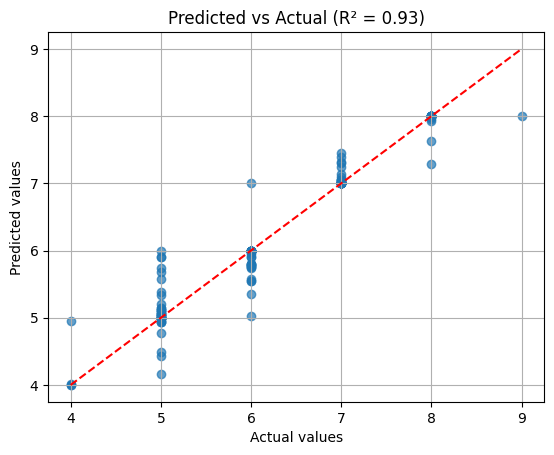

In [ ]:
import matplotlib.pyplot as plt

# Calculate r^2
r2 = r2_score(y_test, y_pred)

# Plot the Predicted vs. Actual values
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--')  # y = x line
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title(f"Predicted vs Actual (R² = {r2:.2f})")
plt.grid(True)
plt.show()

### Residual Plot

A residual plot displays the difference between the actual `Mental_Health_Score` and the predicted `Mental_Health_Score` (these differences are called residuals) against the predicted values. It helps assess the assumptions of linearity, homoscedasticity, and independence of errors.

*   **Ideally**, residuals should be randomly scattered around zero with no discernible pattern, indicating that the model captures most of the variance and errors are random.
*   **Patterns** (e.g., a funnel shape, a curve) suggest that the model might be missing important information, or that the assumptions of the regression model are violated.

Code Block 5D

Mounted at /content/drive


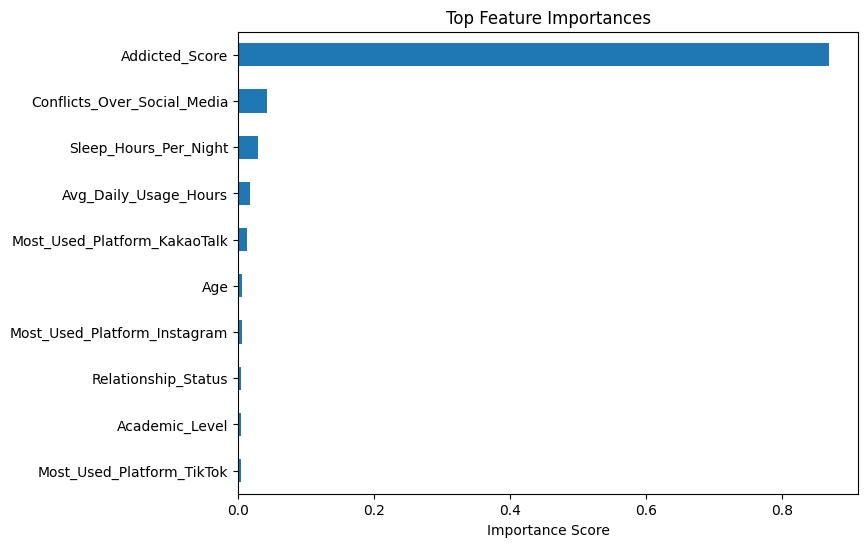

In [ ]:
# --- Imports for Data Manipulation and Model Training (Re-added to ensure dependencies) ---
import pandas as pd                           # For data manipulation and analysis
import numpy as np                            # For numerical operations
from sklearn.model_selection import train_test_split    # To split data into training and testing sets
from sklearn.ensemble import RandomForestRegressor      # Random Forest model for regression tasks
import matplotlib.pyplot as plt               # For plotting and visualizations
import seaborn as sns                         # For advanced statistical visualizations

# --- Mount Drive and Load Data (Re-added to ensure dependencies) ---
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
data_dir = "/content/drive/MyDrive/Social-Media-Project/social_media_addiction.csv"
df = pd.read_csv(data_dir)

# --- Preprocessing steps to recreate df (Re-added to ensure dependencies) ---
# 2.1 Dropping Columns
columns_to_drop = ['Student_ID', 'Country']
df.drop(columns_to_drop, inplace=True, axis=1, errors='ignore')

# 2.2 Label Encoding
gender_mapping = {"Male": 0, "Female":1}
academic_level_mapping = {"High School": 0, "Undergraduate": 1, "Graduate": 2}
performance_mapping = {"No": 0, "Yes": 1}

df['Gender'] = df['Gender'].map(gender_mapping)
df['Academic_Level'] = df['Academic_Level'].map(academic_level_mapping)
df['Affects_Academic_Performance'] = df['Affects_Academic_Performance'].map(performance_mapping)

# 2.3 One-Hot Encoding
columns_to_encode = ['Most_Used_Platform']
df = pd.get_dummies(df, columns=columns_to_encode, drop_first=False)

# Handle 'Relationship_Status' mapping for df if it's still an object type
if 'Relationship_Status' in df.columns and df['Relationship_Status'].dtype == 'object':
    relationship_status_mapping = {'In Relationship': 0, 'Single': 1, 'Complicated': 2}
    df['Relationship_Status'] = df['Relationship_Status'].map(relationship_status_mapping)
    df['Relationship_Status'] = df['Relationship_Status'].fillna(-1) # Fill any potential NaNs

# --- Data splitting (Re-added to ensure dependencies) ---
# Separate the features (independent variables) from the target variable
X = df.drop('Mental_Health_Score', axis=1)

# Set the target variable y as the 'Mental_Health_Score' column
y = df['Mental_Health_Score']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Model Training (Re-added to ensure dependencies) ---
# Initialize a Random Forest Regressor with 100 decision trees
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train (fit) the model using the training data
model.fit(X_train, y_train)

# Get the feature importance scores from the trained model
importances = model.feature_importances_

# Get the names of all features used in training
feature_names = X_train.columns

# Create a Pandas Series with feature names as index and their importances as values
# Then sort them in descending order (most important features first)
feature_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# TODO: Set how many top features you want to visualize
top_n = 10


# Plot a horizontal bar chart of the top N most important features
feature_importances.head(top_n).plot(kind='barh', figsize=(8, 6))

# Invert y-axis so the most important feature appears at the top
plt.gca().invert_yaxis()

# Add title and x-axis label to the plot
plt.title("Top Feature Importances")
plt.xlabel("Importance Score")

# Show the plot
plt.show()

Code Block 5E

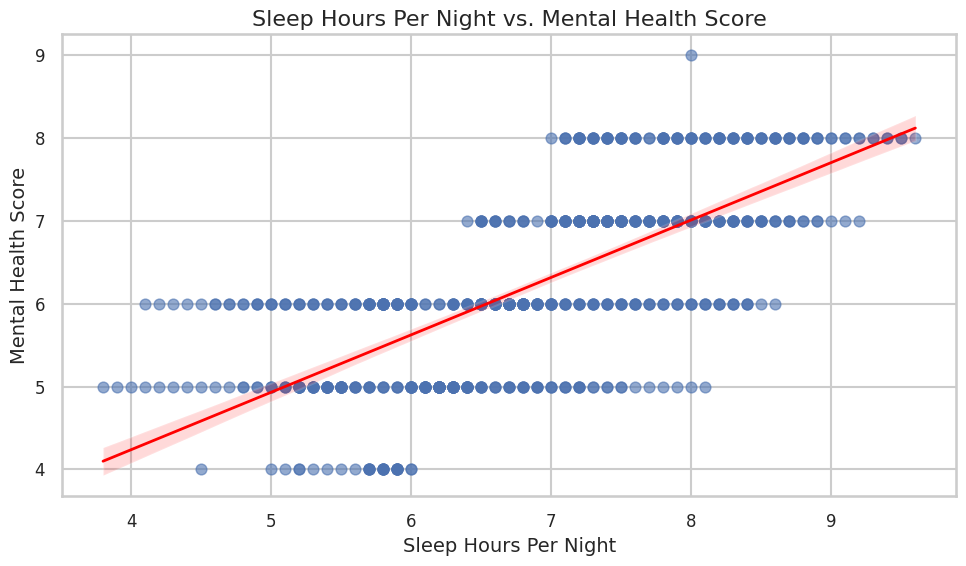

In [ ]:
# TODO: Replace with your desired feature name
feature = 'Sleep_Hours_Per_Night'

# Set aesthetic style
sns.set(style="whitegrid", context="talk")

# Create the plot
plt.figure(figsize=(10, 6))
sns.regplot(
    data=df,
    x=feature,
    y='Mental_Health_Score',
    scatter_kws={"s": 60, "alpha": 0.6},
    line_kws={"color": "red", "lw": 2}
)

# Customize titles and labels
plt.title(f"{feature.replace('_', ' ')} vs. Mental Health Score", fontsize=16)
plt.xlabel(feature.replace('_', ' '), fontsize=14)
plt.ylabel("Mental Health Score", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

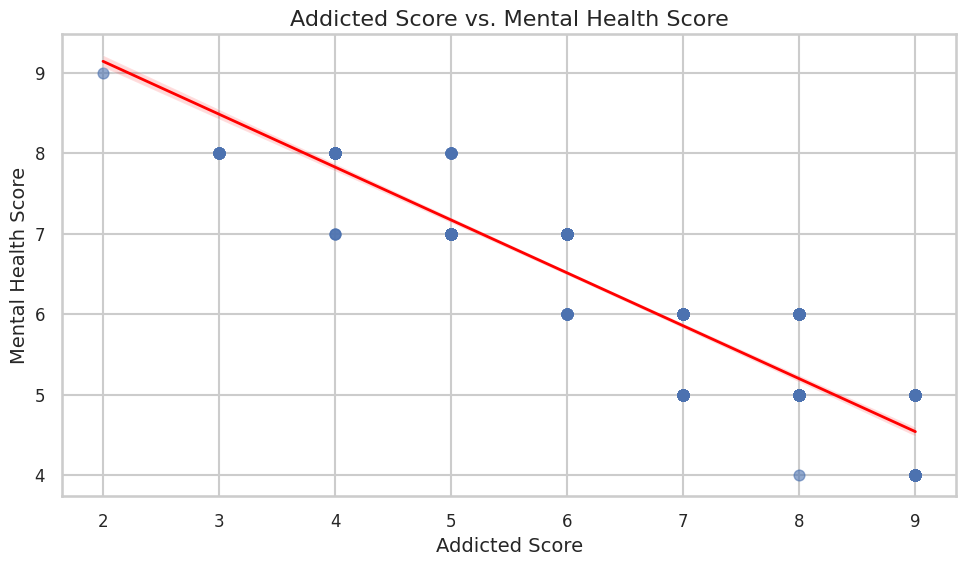

In [ ]:
# TODO: Replace with your desired feature name
feature = 'Addicted_Score'

# Set aesthetic style
sns.set(style="whitegrid", context="talk")

# Create the plot
plt.figure(figsize=(10, 6))
sns.regplot(
    data=df,
    x=feature,
    y='Mental_Health_Score',
    scatter_kws={"s": 60, "alpha": 0.6},
    line_kws={"color": "red", "lw": 2}
)

# Customize titles and labels
plt.title(f"{feature.replace('_', ' ')} vs. Mental Health Score", fontsize=16)
plt.xlabel(feature.replace('_', ' '), fontsize=14)
plt.ylabel("Mental Health Score", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

Mounted at /content/drive


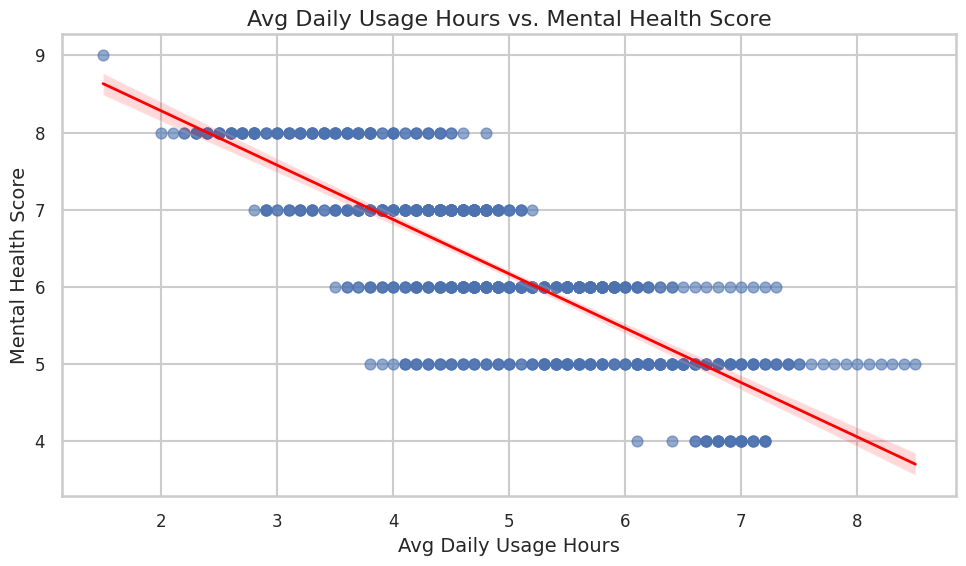

In [ ]:
# TODO: Replace with your desired feature name
feature = 'Avg_Daily_Usage_Hours'

# --- Imports for Data Manipulation ---
import pandas as pd                           # For data manipulation and analysis

# --- Mount Drive and Load Data ---
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
data_dir = "/content/drive/MyDrive/Social-Media-Project/social_media_addiction.csv"
df = pd.read_csv(data_dir)

# --- Preprocessing steps to recreate df ---
# 2.1 Dropping Columns
columns_to_drop = ['Student_ID', 'Country']
df.drop(columns_to_drop, inplace=True, axis=1, errors='ignore')

# 2.2 Label Encoding
gender_mapping = {"Male": 0, "Female":1}
academic_level_mapping = {"High School": 0, "Undergraduate": 1, "Graduate": 2}
performance_mapping = {"No": 0, "Yes": 1}

df['Gender'] = df['Gender'].map(gender_mapping)
df['Academic_Level'] = df['Academic_Level'].map(academic_level_mapping)
df['Affects_Academic_Performance'] = df['Affects_Academic_Performance'].map(performance_mapping)

# 2.3 One-Hot Encoding
columns_to_encode = ['Most_Used_Platform']
df = pd.get_dummies(df, columns=columns_to_encode, drop_first=False)

# Handle 'Relationship_Status' mapping for df if it's still an object type
if 'Relationship_Status' in df.columns and df['Relationship_Status'].dtype == 'object':
    relationship_status_mapping = {'In Relationship': 0, 'Single': 1, 'Complicated': 2}
    df['Relationship_Status'] = df['Relationship_Status'].map(relationship_status_mapping)
    df['Relationship_Status'] = df['Relationship_Status'].fillna(-1) # Fill any potential NaNs

import seaborn as sns
import matplotlib.pyplot as plt

# Set aesthetic style
sns.set(style="whitegrid", context="talk")

# Create the plot
plt.figure(figsize=(10, 6))
sns.regplot(
    data=df,
    x=feature,
    y='Mental_Health_Score',
    scatter_kws={"s": 60, "alpha": 0.6},
    line_kws={"color": "red", "lw": 2}
)

# Customize titles and labels
plt.title(f"{feature.replace('_', ' ')} vs. Mental Health Score", fontsize=16)
plt.xlabel(feature.replace('_', ' '), fontsize=14)
plt.ylabel("Mental Health Score", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

Code Block 5F

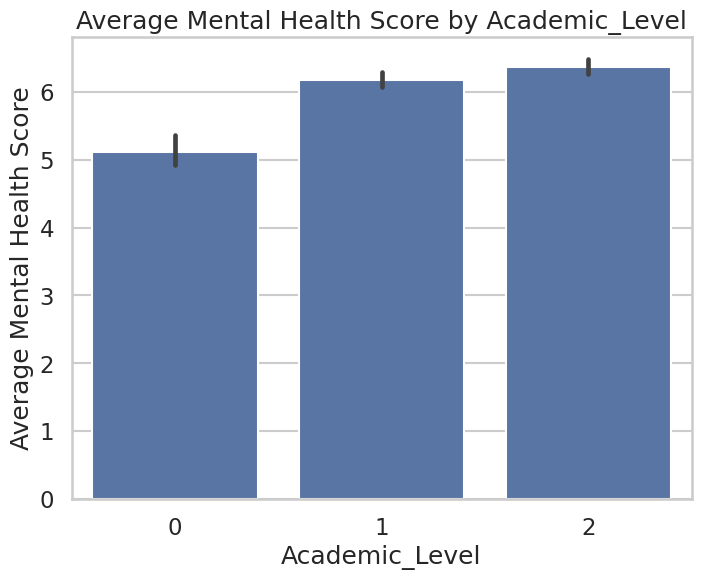

In [ ]:
# TODO: Replace with your feature name
feature = 'Academic_Level'

plt.figure(figsize=(8, 6))
sns.barplot(data=df, x=feature, y='Mental_Health_Score')
plt.title(f'Average Mental Health Score by {feature}')
plt.xlabel(feature)
plt.ylabel('Average Mental Health Score')
plt.show()

Remember this could be skewed. There could be more High Schoolers. Or maybe it because they are more likely to use social media.

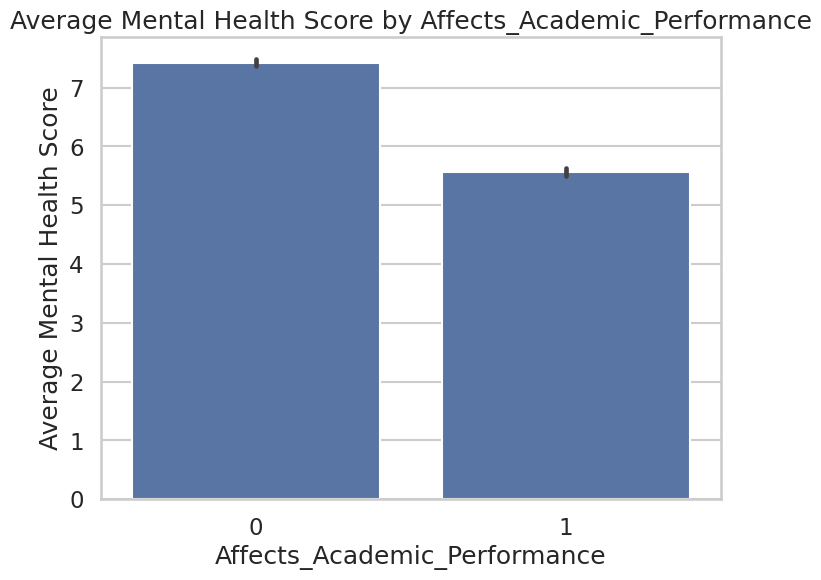

In [ ]:
# TODO: Replace with your feature name
feature = 'Affects_Academic_Performance'

plt.figure(figsize=(8, 6))
sns.barplot(data=df, x=feature, y='Mental_Health_Score')
plt.title(f'Average Mental Health Score by {feature}')
plt.xlabel(feature)
plt.ylabel('Average Mental Health Score')
plt.show()

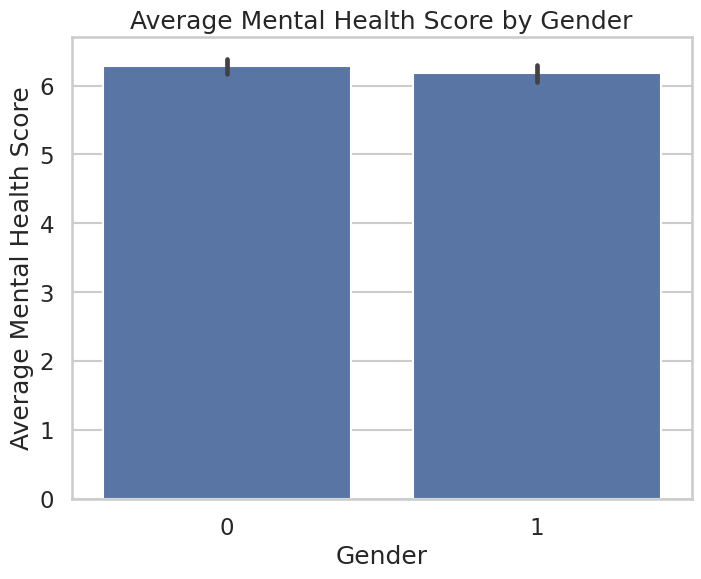

In [ ]:
# TODO: Replace with your feature name
feature = 'Gender'

plt.figure(figsize=(8, 6))
sns.barplot(data=df, x=feature, y='Mental_Health_Score')
plt.title(f'Average Mental Health Score by {feature}')
plt.xlabel(feature)
plt.ylabel('Average Mental Health Score')
plt.show()

Code Block 5G

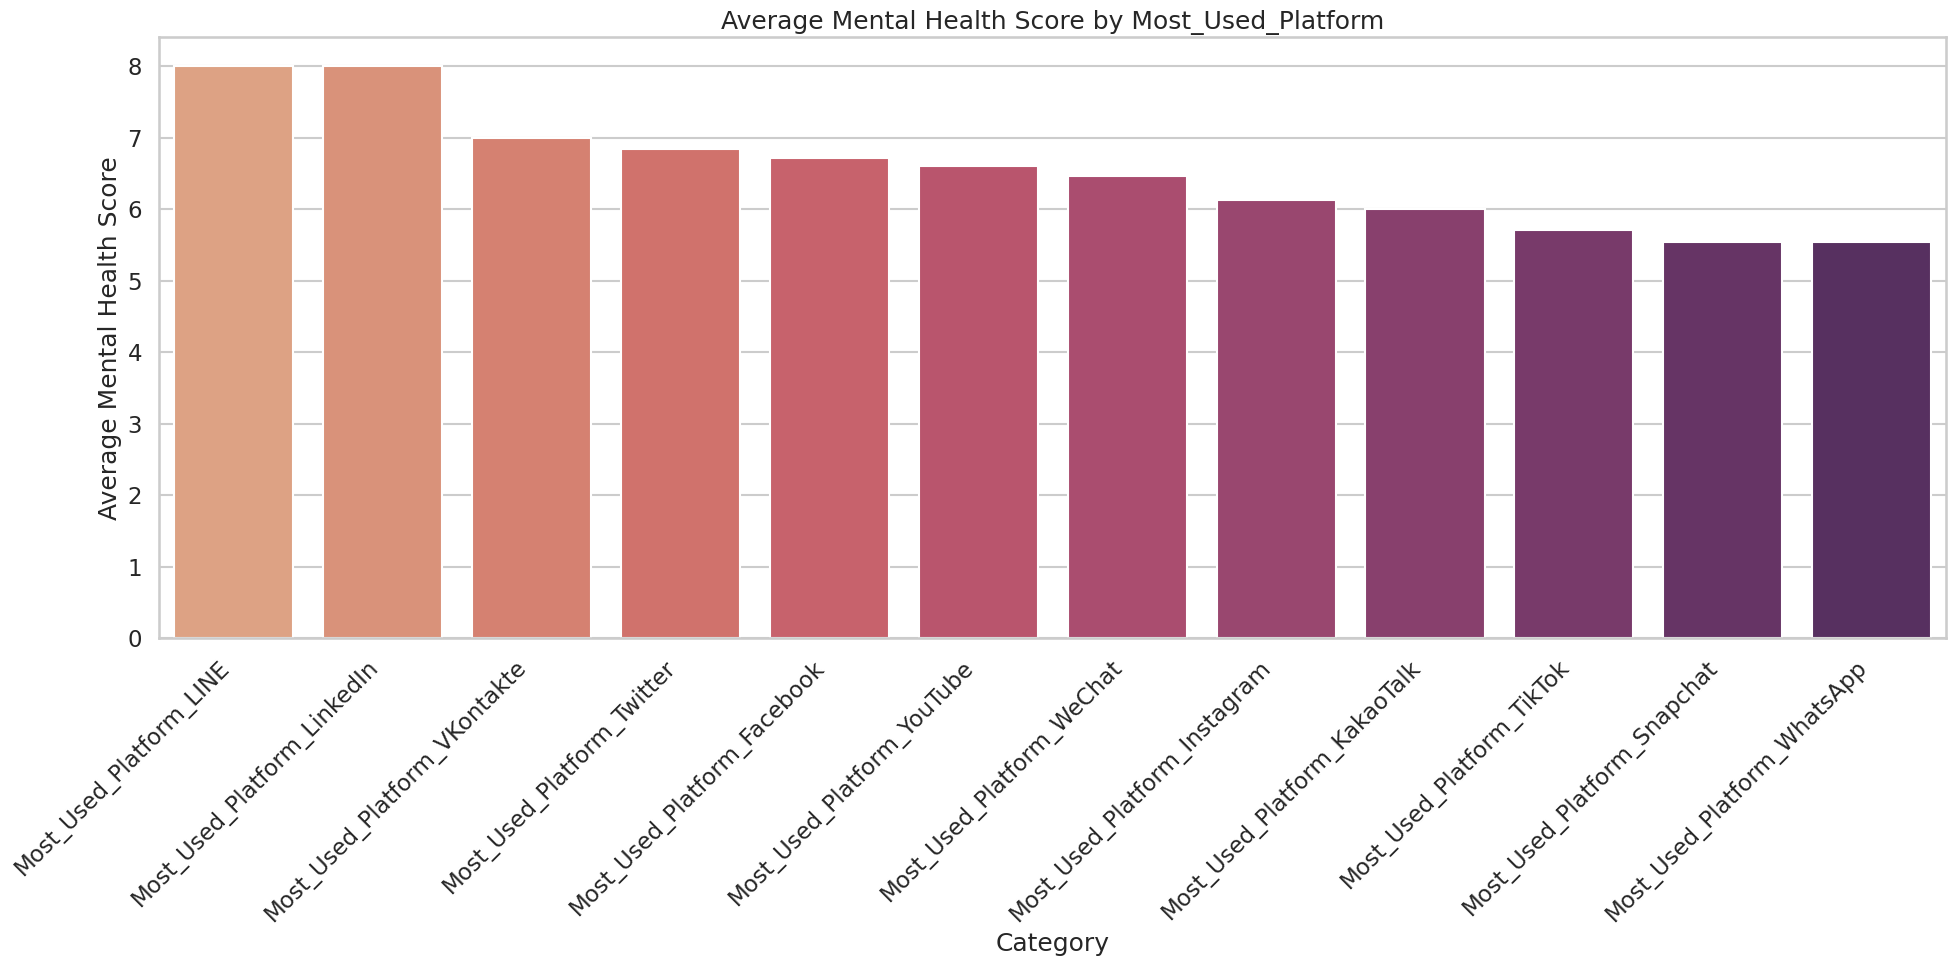

In [ ]:
# TODO: Replace with feature with multiple categories
feature = "Most_Used_Platform"

# Filter one-hot encoded columns that represent the positive classes of categorical variables
# (assuming original variable was dropped after one-hot encoding)
binary_columns = [col for col in df.columns if col.startswith(tuple([feature + '_']))]

# Calculate the mean Mental Health Score for when each binary column is 1 (i.e., the "positive" class)
avg_scores = {}
for col in binary_columns:
    avg_scores[col] = df[df[col] == 1]['Mental_Health_Score'].mean()

# Convert to DataFrame for plotting
avg_scores_df = pd.DataFrame(list(avg_scores.items()), columns=['Category', 'Average_Mental_Health_Score'])
avg_scores_df = avg_scores_df.sort_values(by='Average_Mental_Health_Score', ascending=False)

# Plot
plt.figure(figsize=(20, 10))
sns.barplot(data=avg_scores_df, x='Category', y='Average_Mental_Health_Score', hue='Category', palette='flare', legend=False)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Average Mental Health Score')
plt.title('Average Mental Health Score by ' + feature)
plt.tight_layout()
plt.show()

### Residual Plot

A residual plot displays the difference between the actual `Mental_Health_Score` and the predicted `Mental_Health_Score` (these differences are called residuals) against the predicted values. It helps assess the assumptions of linearity, homoscedasticity, and independence of errors.

*   **Ideally**, residuals should be randomly scattered around zero with no discernible pattern, indicating that the model captures most of the variance and errors are random.
*   **Patterns** (e.g., a funnel shape, a curve) suggest that the model might be missing important information, or that the assumptions of the regression model are violated.

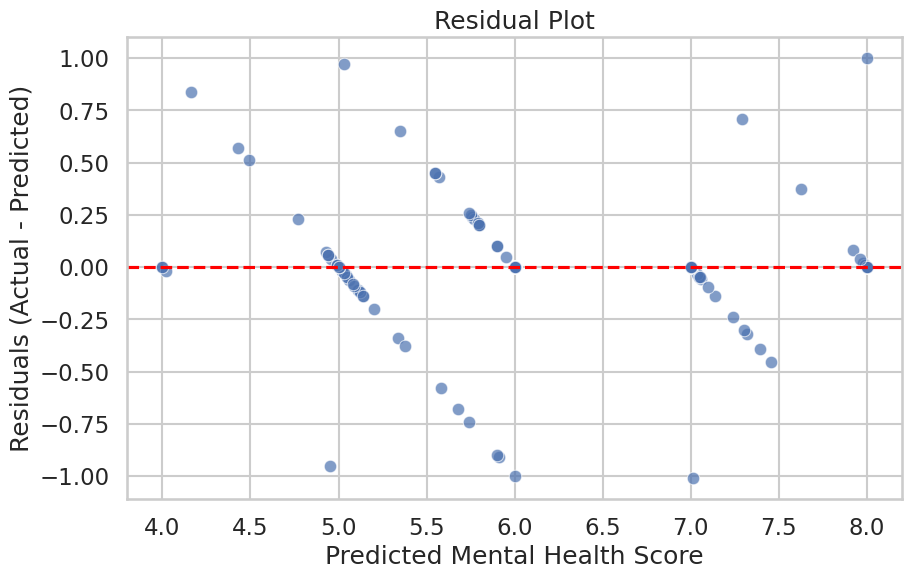

In [ ]:
# Use the trained model to predict the target values for the test feature set
y_pred = model.predict(X_test)

# Calculate residuals
residuals = y_test - y_pred

import seaborn as sns
import matplotlib.pyplot as plt

# Create a residual plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--') # Add a horizontal line at y=0
plt.xlabel("Predicted Mental Health Score")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot")
plt.grid(True)
plt.show()

# Optional: Explore Additional Graphs

Code Block 6A

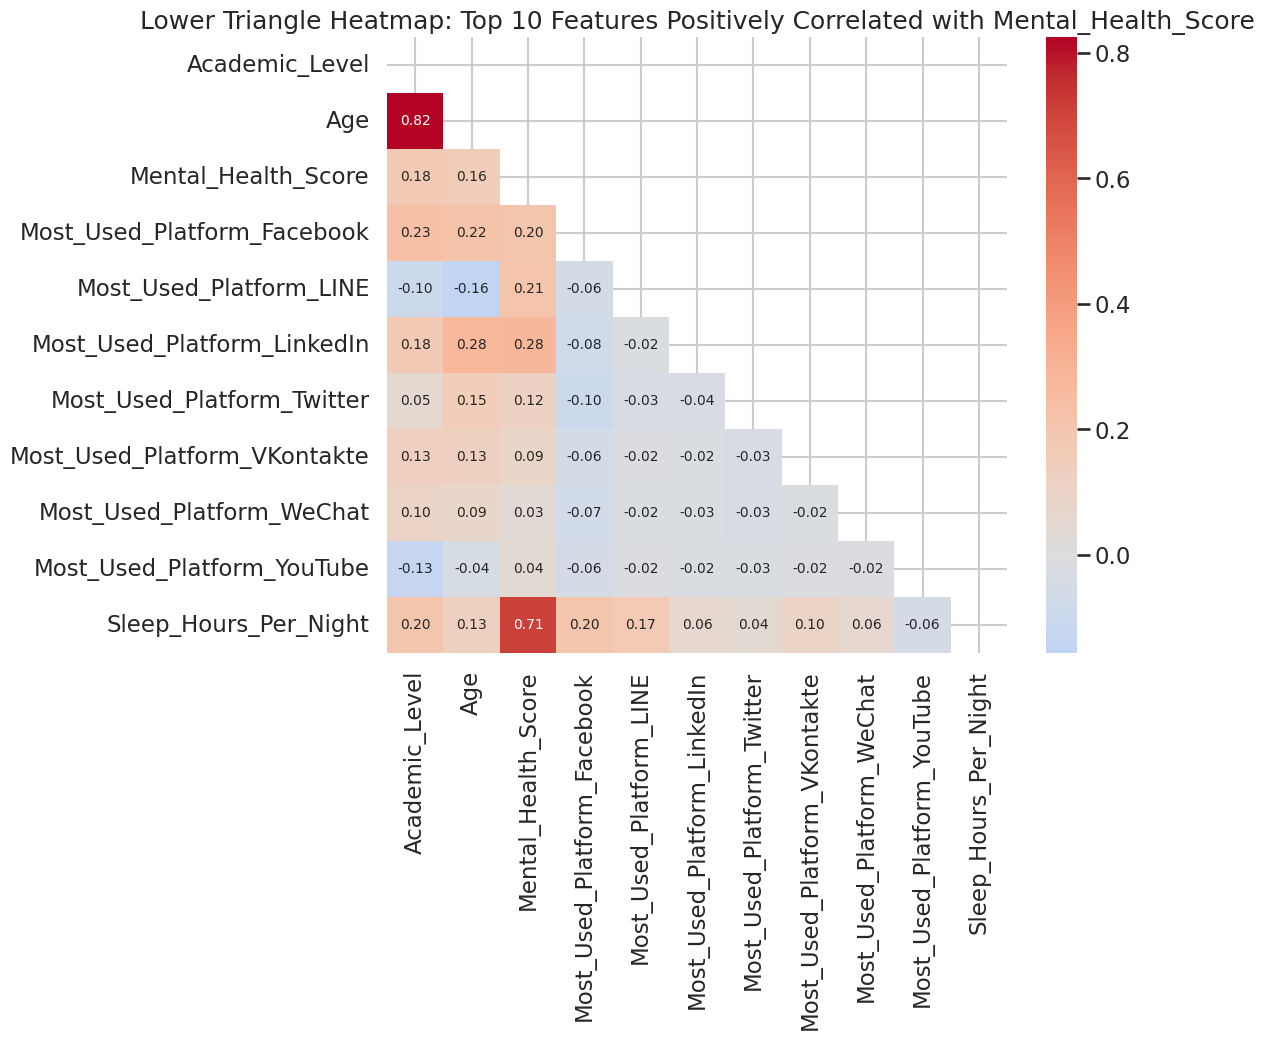

In [ ]:
# Map 'Relationship_Status' to numerical values for correlation calculation
relationship_status_mapping = {'In Relationship': 0, 'Single': 1, 'Complicated': 2}
df['Relationship_Status'] = df['Relationship_Status'].map(relationship_status_mapping)

# Compute correlation matrix
correlations = df.corr()

# Select top 10 features most positively correlated with 'Mental_Health_Score' (excluding itself)
top_corr_features = correlations['Mental_Health_Score'].drop('Mental_Health_Score').sort_values(ascending=False).head(10).index

# Subset the DataFrame to these features + target
top_corr_matrix = df[top_corr_features.union(['Mental_Health_Score'])].corr()

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(top_corr_matrix, dtype=bool))

# Plot the heatmap with the mask applied to show only the lower triangle
plt.figure(figsize=(10, 8))
sns.heatmap(top_corr_matrix, mask=mask, annot=True, cmap='coolwarm', center=0, annot_kws={"size":10}, fmt=".2f")
plt.title("Lower Triangle Heatmap: Top 10 Features Positively Correlated with Mental_Health_Score")
plt.show()

Code Block 6B

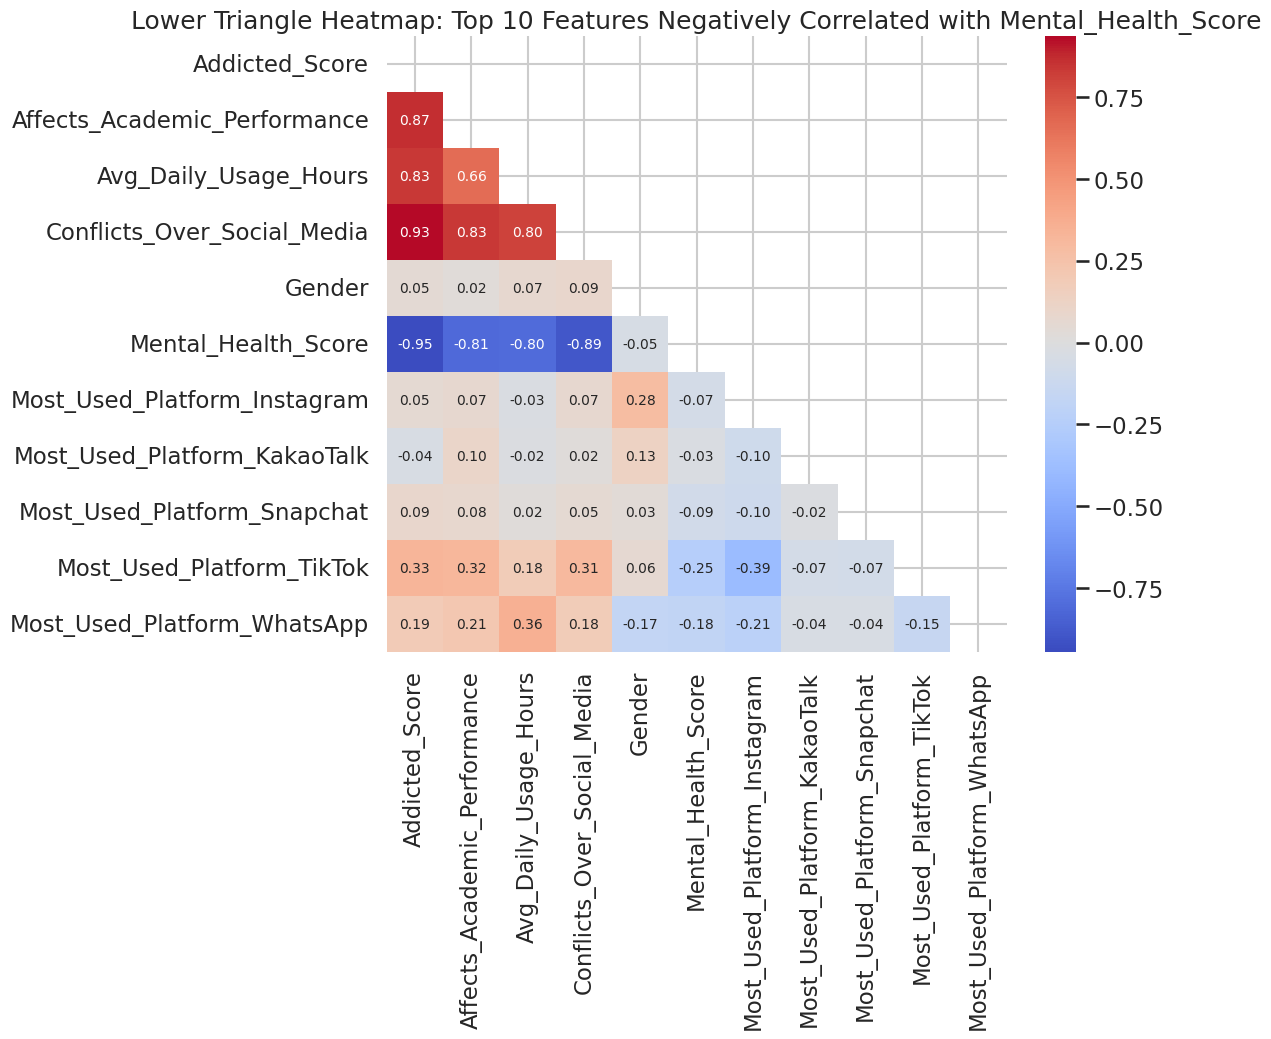

In [ ]:
# Compute correlation matrix
correlations = df.corr()

# Select top 10 features most negatively correlated with 'Mental_Health_Score' (lowest correlation values)
top_neg_corr_features = correlations['Mental_Health_Score'].drop('Mental_Health_Score').sort_values(ascending=True).head(10).index

# Subset the DataFrame to these features + target
top_neg_corr_matrix = df[top_neg_corr_features.union(['Mental_Health_Score'])].corr()

# Create a mask for the upper triangle to show only the lower triangle
mask = np.triu(np.ones_like(top_neg_corr_matrix, dtype=bool))

# Plot the heatmap with the mask applied
plt.figure(figsize=(10, 8))
sns.heatmap(top_neg_corr_matrix, mask=mask, annot=True, cmap='coolwarm', center=0, annot_kws={"size":10}, fmt=".2f")
plt.title("Lower Triangle Heatmap: Top 10 Features Negatively Correlated with Mental_Health_Score")
plt.show()